In [19]:
import pandas as pd

In [2]:
df = pd.read_csv("wildfire.csv")

In [20]:
df.head()

,latitude,longitude,datetime,pr,rmax,rmin,srad,tmmn,tmmx,vs,fm100,fm1000,erc,vpd,cluster
0,34.07454,-117.99891,2018-08-08,0.0,65.0,21.2,323.2,294.9,309.2,2.1,8.0,9.8,66.0,2.68,1
1,34.07454,-117.99891,2018-08-09,0.0,64.4,18.0,286.1,295.3,311.6,2.5,7.8,9.7,68.0,3.11,1
2,34.07454,-117.99891,2018-08-10,0.0,77.0,31.0,312.0,295.5,307.9,2.7,8.6,9.7,64.0,2.11,1
3,34.07454,-117.99891,2018-08-11,0.0,84.5,36.7,311.8,294.8,306.5,2.3,9.7,9.7,61.0,1.72,1
4,34.07454,-117.99891,2018-08-12,0.0,90.4,38.7,313.5,293.4,305.5,2.9,10.9,9.9,59.0,1.50,0


In [21]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [22]:
feature_cols = ["pr", "rmax", "rmin", "srad", "tmmn", "tmmx", "vs", "fm100", "fm1000", "vpd"] # enviro features except erc (label)

In [23]:
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])

In [24]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=5, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

In [25]:
sample = df.sample(n=5000, random_state=5)

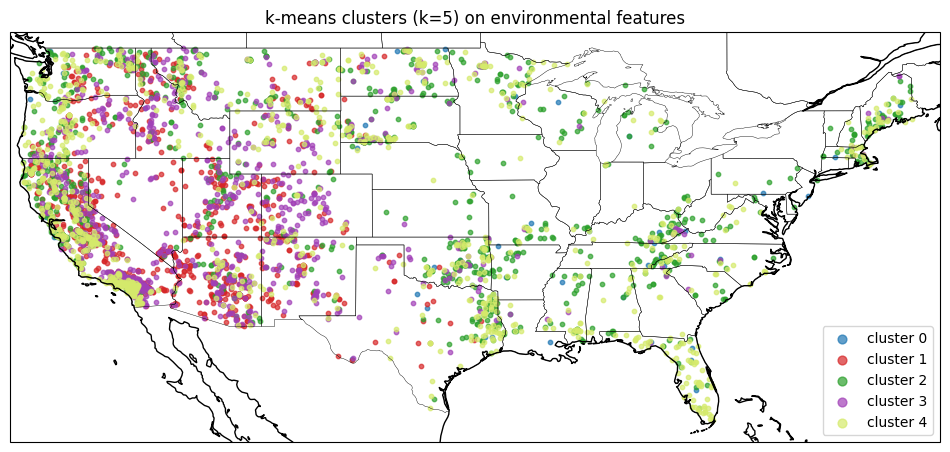

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

k = 5

# pick distinct, high-contrast colors manually
colors = ["#1f77b4", "#d62728", "#2ca02c", "#A140B7", "#d5ea6b"]
cmap = mcolors.ListedColormap(colors)

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.add_feature(cfeature.COASTLINE)

for i in range(k):
    cluster_data = sample[sample["cluster"] == i]
    ax.scatter(
        cluster_data["longitude"], cluster_data["latitude"],
        color=colors[i], s=10, alpha=0.7,
        label=f"cluster {i}", transform=ccrs.PlateCarree()
    )

ax.legend(loc="lower right", markerscale=2, fontsize=10)
plt.title(f"k-means clusters (k={k}) on environmental features")
plt.show()